In [1]:
from pandas import date_range

"""
Based on the paper of Simpson & Woolway (2021)
https://agupubs.onlinelibrary.wiley.com/doi/10.1029/2020WR029441
"""

'\nBased on the paper of Simpson & Woolway (2021)\nhttps://agupubs.onlinelibrary.wiley.com/doi/10.1029/2020WR029441\n'

In [2]:
import pandas as pd
import numpy as np
import xarray as xr
import os
import matplotlib.pyplot as plt

import sys
sys.path.append('..//')
from utils_mitgcm import open_mitgcm_ds_from_config
from utils_energy_analysis import *

In [58]:
lake = 'lucerne'

In [59]:
base_folder = rf"/storage/alplakes_test/{lake}_100m_2025"

In [60]:
output_folder = os.path.join(base_folder, 'wind_analysis')
os.makedirs(output_folder, exist_ok=True)

In [70]:
bin_folder = os.path.join(rf'/home/leroquan@eawag.wroot.emp-eaw.ch/work_space/{lake}_100m_2025', 'binary_data')

In [71]:
suffix=''

In [72]:
def save_as_compressed_netcdf(ds: xr.DataArray, name: str, path: str):
    ds.name = name

    encoding = {
        name: {
            "zlib": True,
            "complevel": 4,     # 1–9, 4 is a good default
        }
    }

    ds.to_netcdf(path, encoding=encoding)

# Import datasets

da_eddy_mask = xr.open_dataarray(os.path.join(base_folder, 'outputs_swirl', 'eddy_catalogues_final', 'eddy_mask.nc'))
da_eddy_mask = da_eddy_mask.isel(Z=0)
da_eddy_mask = da_eddy_mask.rename({'XC': 'x', 'YC': 'y'})

In [73]:
ds_wind = xr.open_dataset(os.path.join(bin_folder, "wind.nc"))
ds_wind['time'] = ds_wind.time + np.timedelta64(30, 'm')
#ds_wind = ds_wind.sel(time=slice('2025-01-01T00:30:00.000000000', '2026-01-01T00:00:00.000000000'))
#ds_wind['x'] = da_eddy_mask['x']
#ds_wind['y'] = da_eddy_mask['y']

suffix='_eddies'
ds_wind = ds_wind.where(da_eddy_mask)

In [74]:
model = f'{lake}_2025'
mitgcm_config, ds = open_mitgcm_ds_from_config('..//config.json', model)

In [75]:
grid_resolution = 100

In [76]:
ds['YC'] = np.arange(1, len(ds['YC']) + 1) * grid_resolution - grid_resolution / 2
ds['XC'] = np.arange(1, len(ds['XC']) + 1) * grid_resolution - grid_resolution / 2
ds['YG'] = np.arange(0, len(ds['YG'])) * grid_resolution
ds['XG'] = np.arange(0, len(ds['XG'])) * grid_resolution

In [77]:
mask = ds['THETA'].isel(time=0).values > 0

# Wind stress components ($\tau_x$ & $\tau_y$)

### Cd

In [78]:
# Following the MITgcm calculation
drag_coeff1 = 0.0027 #0.00135
drag_coeff2 = 0.000142 #0.000071
drag_coeff3 = 7.64e-05 #0.0000382

def compute_cd(wind_speed):
    cd = drag_coeff1 / wind_speed + drag_coeff2 + drag_coeff3 * wind_speed
    return cd

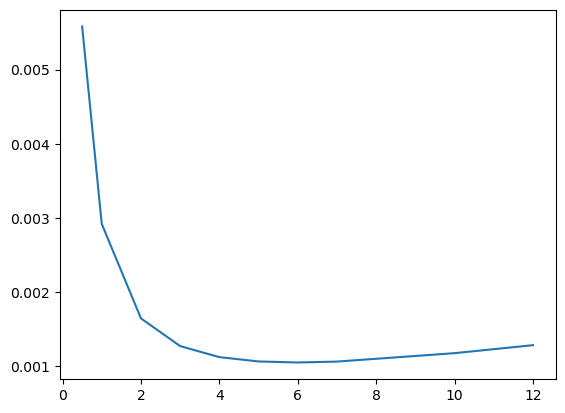

In [79]:
test_speed_arr = np.array([0.5, 1, 2 ,3, 4, 5, 6, 7, 10, 12])
plt.plot(test_speed_arr, compute_cd(test_speed_arr))

In [15]:
cd = compute_cd(ds_wind.speed)

In [16]:
cd.to_netcdf(os.path.join(output_folder, 'Cd.nc'))

In [80]:
cd = xr.open_dataarray(os.path.join(output_folder, 'Cd.nc'))
cd['time'] = ds_wind['time']
cd['x'] = ds_wind['x']
cd['y'] = ds_wind['y']

CoordinateValidationError: conflicting sizes for dimension 'time': length 8760 on the data but length 8761 on coordinate 'time'

In [ ]:
cd.time

# $\tau_x$ & $\tau_y$

In [11]:
rho_a = 1.225 # 15°C, kg/m3

In [19]:
tau_x = cd * rho_a * (ds_wind.u10*np.abs(ds_wind.u10)) # - * kg/m3 * m2/s2 = kg/s2/m
tau_y = cd * rho_a * (ds_wind.v10*np.abs(ds_wind.v10))

In [20]:
save_as_compressed_netcdf(tau_x, 'tau_x', os.path.join(output_folder, f'wind_tau_x{suffix}.nc'))
save_as_compressed_netcdf(tau_y, 'tau_y', os.path.join(output_folder, f'wind_tau_y{suffix}.nc'))

In [30]:
tau_x = xr.open_dataarray(os.path.join(output_folder, f'wind_tau_x{suffix}.nc'))
tau_y = xr.open_dataarray(os.path.join(output_folder, f'wind_tau_y{suffix}.nc'))

# Wind Rate of Working

In [17]:
ds_surface = ds.isel(Z=0)

u = ds_surface.UVEL.rename({'XG':'x', 'YC':'y'})
u['x'] = tau_x['x']
u['y'] = tau_y['y']
v = ds_surface.VVEL.rename({'XC':'x', 'YG':'y'})
v['y'] = tau_y['y']
v['x'] = tau_x['x']

In [18]:
tau_x_crop = tau_x.sel(time=slice(u.time.values[0],u.time.values[-1]))
tau_y_crop = tau_y.sel(time=slice(u.time.values[0],u.time.values[-1]))

In [19]:
u['time'] = tau_x_crop.time
v['time'] = tau_x_crop.time

In [20]:
RW = tau_x * u + tau_y * v # kg/s2/m * m/s = kg/s3 = m2/m2 * kg/s3 = kg*m2/s3 /m2 = W/m2

In [21]:
save_as_compressed_netcdf(RW, 'RW', os.path.join(output_folder, f'wind_RW_Wperm2{suffix}.nc'))

KeyboardInterrupt: 

In [33]:
RW = xr.open_dataarray(os.path.join(output_folder, f'wind_RW_Wperm2{suffix}.nc')) # W/m2

In [ ]:
RW_mean = RW.mean(dim=['x', 'y'])

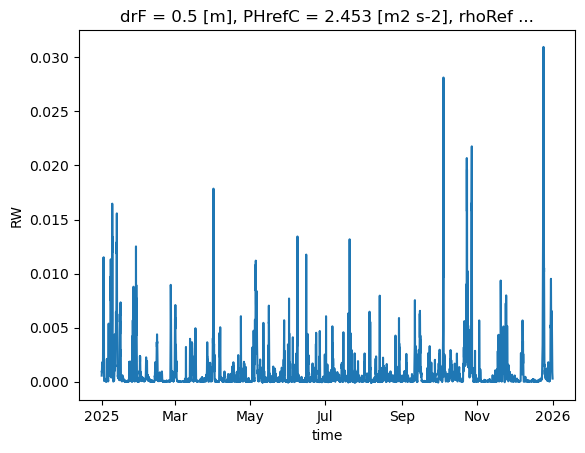

In [ ]:
RW_mean.plot()

In [ ]:
RW_mean.to_netcdf(os.path.join(base_folder, 'wind_analysis', f'mean_wind_RW_Wperm2{suffix}.nc'))

In [66]:
RW_mean = xr.open_dataarray(os.path.join(base_folder, 'wind_analysis', f'mean_wind_RW_Wperm2{suffix}.nc'))

<xarray.DataArray 'time' (time: 8760)> Size: 70kB
array(['2025-01-01T00:30:00.000000000', '2025-01-01T01:30:00.000000000',
       '2025-01-01T02:30:00.000000000', ..., '2025-12-31T21:30:00.000000000',
       '2025-12-31T22:30:00.000000000', '2025-12-31T23:30:00.000000000'],
      shape=(8760,), dtype='datetime64[ns]')
Coordinates:
    drF      float32 4B ...
    PHrefC   float32 4B ...
    rhoRef   float32 4B ...
    Z        float64 8B ...
  * time     (time) datetime64[ns] 70kB 2025-01-01T00:30:00 ... 2025-12-31T23...
    iter     (time) int64 70kB ...

In [ ]:
nb_cells = RW.isel(time=0).count()
cell_area = grid_resolution**2
total_area = nb_cells * cell_area

In [57]:
total_area.values

array(206200000)

In [ ]:
E_input_wind = RW_mean * 3600 * total_area/1e6 # W/m2=J/s/m2 --> MJ/h

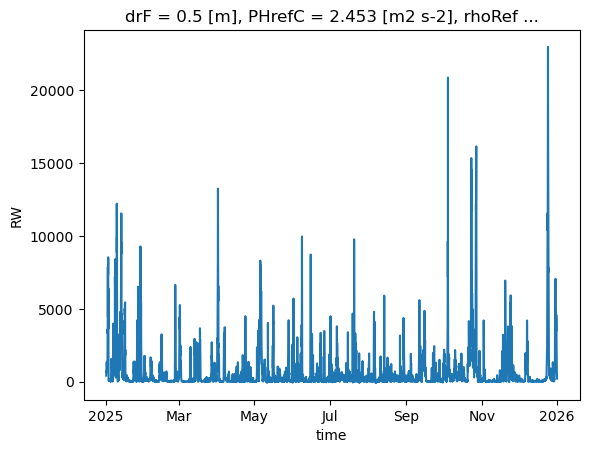

In [ ]:
E_input_wind.plot()

In [ ]:
E_input_wind.name = "E_wind_MJperh"
E_input_wind.to_netcdf(os.path.join(base_folder, 'wind_analysis', f'E_wind_MJperh{suffix}.nc'))

In [ ]:
E_input_wind = xr.open_dataset(os.path.join(base_folder, 'wind_analysis', f'E_wind_MJperh{suffix}.nc'))

In [ ]:
E_input_wind.to_dataframe()['E_wind_MJperh'].reset_index().to_csv(os.path.join(base_folder, 'wind_analysis', f'E_wind_MJperh{suffix}.csv'))

# Energy transfer efficiency

In [37]:
P10 = cd * rho_a * (ds_wind.speed**3)  # - * kg/m3 * m3/s3 = kg/s3 =  W/m2
#P10['time'] = P10.time + np.timedelta64(30, 'm')

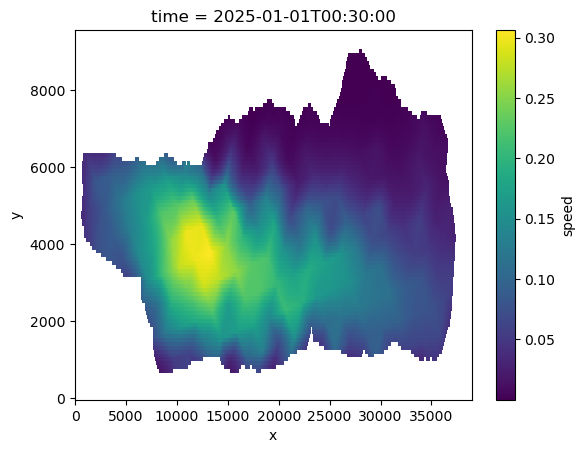

In [38]:
P10.isel(time=0).plot()

In [15]:
df_P10 = P10.mean(dim=['x', 'y']).to_dataframe(name='P10_Wperm2')
df_P10['P10_MJperh'] = P10.sum(dim=['x', 'y']).to_dataframe(name='P10_MJperh')* (grid_resolution**2) * 3600/1e6
df_P10.to_csv(os.path.join(base_folder, 'wind_analysis', f'P10.csv'))

In [39]:
# Make a 20-day bin label coordinate
bin20 = RW["time"].dt.floor("20D")

# Numerator and denominator grouped by bin
num = RW.groupby(bin20).sum("time", skipna=True)
den = P10.isel(time=range(0,len(P10.time)-1)).groupby(bin20).sum("time", skipna=True)

Eff_20d = xr.where(den > 0, num / den, np.nan).rename("Eff")

# Rename the new dimension to "time"
Eff_20d = Eff_20d.rename({"floor": "time"})


In [53]:
RW.mean()

<xarray.DataArray 'RW' ()> Size: 8B
array(0.00053597)
Coordinates:
    drF      float32 4B ...
    PHrefC   float32 4B ...
    rhoRef   float32 4B ...
    Z        float64 8B ...

In [40]:
Eff_20d.to_netcdf(os.path.join(base_folder, 'wind_analysis', f'efficiency_20d{suffix}.nc'))

In [63]:
Eff_20d = xr.open_dataarray(os.path.join(base_folder, 'wind_analysis', f'efficiency_20d{suffix}.nc'))

Text(0, 0.5, 'Efficiency [%]')

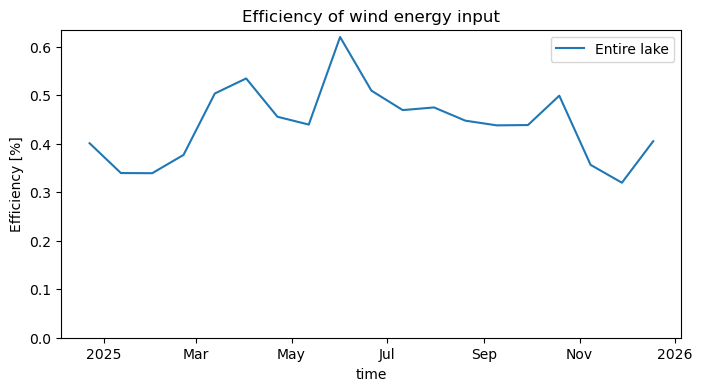

In [64]:
fig = plt.figure(figsize=(8, 4))
(Eff_20d.mean(dim=['x', 'y'])*100).plot(label='Entire lake')
plt.title('Efficiency of wind energy input')
plt.ylim(bottom=0)
plt.legend()
plt.grid(False)
plt.ylabel('Efficiency [%]')

In [65]:
(Eff_20d.mean(dim=['x', 'y'])*100).mean()

<xarray.DataArray 'Eff' ()> Size: 8B
array(0.44024017)
Coordinates:
    drF      float32 4B ...
    PHrefC   float32 4B ...
    rhoRef   float32 4B ...
    Z        float64 8B ...